# Machine learning pipeline for Immune cell type classification 

## Notebook 1: Exploratory Data Analysis 

In [1]:
#Major Imports
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Setting up relative paths and directories
RAND_SEED: int = 7 #Coz, 007, why not?!

DATA_DIR:      str = os.path.join(os.path.dirname(os.getcwd()),"Data")
RESULTS_DIR:   str = os.path.join(os.path.dirname(os.getcwd()),"Results")
PLOT_DIR:      str = os.path.join(os.path.dirname(os.getcwd()),"Plots")
MODEL_DIR:     str = os.path.join(os.path.dirname(os.getcwd()),"Models")

for d in [DATA_DIR, RESULTS_DIR, PLOT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

In [3]:
#Quick preview at the data
preview = pd.read_csv(
    os.path.join(DATA_DIR,"batch_corrected_expression_with_celltypes.tsv"),
    sep="\t",
    nrows=5
)
print(preview.shape)
print(preview.columns[:5].tolist())
preview.head()

(5, 2002)
['Unnamed: 0', 'PPBP', 'PTGDS', 'GNLY', 'FCER1A']


,Unnamed: 0,PPBP,PTGDS,GNLY,FCER1A,PF4,GZMB,MZB1,S100A9,C1QB,...,SLBP,SLC25A22,TMEM205,MORC2,CD1B,PPIL2,TCF19,PRKCB,SKA1,CellType
0,TCCCGATGTTAAGATG-1_7,-0.067185,-0.061965,-0.072270,-0.006314,0.040835,-0.018003,-0.010423,5.596175,-0.000241,...,1.366634,0.022373,0.315363,0.010218,-0.000288,0.169300,-0.010009,0.731021,0.004238,CD14 Mono
1,TTTCGATCACATTACG-1_1,-0.090013,0.010048,0.005502,0.006034,0.014521,-0.102739,-0.001492,3.366856,0.012824,...,0.692414,0.065046,0.572243,0.030051,-0.016936,0.191588,-0.004734,-0.164890,0.018072,CD14 Mono
2,AATGCCAGTGGACCAA-1_5,0.013690,0.004790,-0.030905,0.003231,0.000244,-0.053223,-0.015890,5.021750,-0.000076,...,0.393901,-0.004960,0.115961,0.483775,-0.006629,0.184109,-0.001498,1.300231,-0.001369,CD14 Mono
3,CTTAGGAAGCCAACAG-1_8,0.058790,-0.019925,0.656104,0.017998,-0.001272,0.084636,-0.108972,5.458511,-0.000183,...,0.893983,0.015698,-0.108487,0.109554,-0.000833,0.200299,-0.108342,0.462959,0.001720,CD14 Mono
4,GAATCACGTATTTCCT-1_13,0.005776,0.012726,-0.046718,-0.046348,0.006890,0.004545,-0.007758,5.781392,0.000009,...,0.274805,0.009353,0.527105,0.137788,-0.000670,0.159736,0.001091,1.009797,0.007636,CD14 Mono


What we are looking at:

1. 2002 total columns: "Unnamed: 0" is the cell barcode; then there are 2000 gene expression columns; and lastly the "CellType" label column.
2. On a quick glance, the feature values look like they have been appropriately scaled and normalised during the Seurat preprocessing stage. That is in line with the filename, i.e. "batch corected"

In [4]:
#Initiating the full load of the data
rna_seq_data = pd.read_csv(
    os.path.join(DATA_DIR, "batch_corrected_expression_with_celltypes.tsv"),
    sep = "\t",
    index_col=0
)

print(f"Shape of the data: {rna_seq_data.shape}")
print(f"Memory Usage in GB: {round(rna_seq_data.memory_usage(deep=True).sum()/1e9,2)}")
print(f"LAst Column: {rna_seq_data.columns[-1]}")
rna_seq_data.head()

Shape of the data: (76893, 2001)
Memory Usage in GB: 1.24
LAst Column: CellType


,PPBP,PTGDS,GNLY,FCER1A,PF4,GZMB,MZB1,S100A9,C1QB,C1QA,...,SLBP,SLC25A22,TMEM205,MORC2,CD1B,PPIL2,TCF19,PRKCB,SKA1,CellType
TCCCGATGTTAAGATG-1_7,-0.067185,-0.061965,-0.072270,-0.006314,0.040835,-0.018003,-0.010423,5.596175,-0.000241,-0.007603,...,1.366634,0.022373,0.315363,0.010218,-0.000288,0.169300,-0.010009,0.731021,0.004238,CD14 Mono
TTTCGATCACATTACG-1_1,-0.090013,0.010048,0.005502,0.006034,0.014521,-0.102739,-0.001492,3.366856,0.012824,-0.009514,...,0.692414,0.065046,0.572243,0.030051,-0.016936,0.191588,-0.004734,-0.164890,0.018072,CD14 Mono
AATGCCAGTGGACCAA-1_5,0.013690,0.004790,-0.030905,0.003231,0.000244,-0.053223,-0.015890,5.021750,-0.000076,0.334029,...,0.393901,-0.004960,0.115961,0.483775,-0.006629,0.184109,-0.001498,1.300231,-0.001369,CD14 Mono
CTTAGGAAGCCAACAG-1_8,0.058790,-0.019925,0.656104,0.017998,-0.001272,0.084636,-0.108972,5.458511,-0.000183,0.015630,...,0.893983,0.015698,-0.108487,0.109554,-0.000833,0.200299,-0.108342,0.462959,0.001720,CD14 Mono
GAATCACGTATTTCCT-1_13,0.005776,0.012726,-0.046718,-0.046348,0.006890,0.004545,-0.007758,5.781392,0.000009,-0.002512,...,0.274805,0.009353,0.527105,0.137788,-0.000670,0.159736,0.001091,1.009797,0.007636,CD14 Mono


Nexxt we move ahead with a rudimentary data sanity check on whether we have missing values, infinitie values, non numeric characters etc. in the dataset which could contaminate the downstream analysis. On top of that, we will also ensure that each of the individual cell in this gene expression matrix has a unique cell barcode. 

In [5]:
#Isolating the gene feature columns 
gene_columns = rna_seq_data.columns[:-1] #All the way upto but not including CellTypes columns

# Missing values (Nan)
n_missing = rna_seq_data.isna().sum().sum()
print(f"Total count of missing values: {n_missing}")

#Infinite values
n_infinite = np.isinf(rna_seq_data[gene_columns]).sum().sum()
print(f"Infinite values found: {n_infinite}")


#Duplicates in gene identifier barcodes
n_duplicates = rna_seq_data.index.duplicated().sum()
print(f"Duplicated index entries: {n_duplicates}")

#Non numeric 
non_numeric = rna_seq_data[gene_columns].select_dtypes(exclude=[np.number]).columns
print(f"Names of the non numeric gene columns: {list(non_numeric)}")

Total count of missing values: 0
Infinite values found: 0
Duplicated index entries: 0
Names of the non numeric gene columns: []


The above output indicates that I can now go ahead with cell type analysis and dimensionality reduciton work without worrying about the structural integrity of the data. 

## Analysing Cell types and their distribution 

In [6]:
#Calculating cell counts and % per each cell type


cell_type_counts = rna_seq_data["CellType"].value_counts()
cell_type_df = pd.DataFrame(
    {
        "CellType": cell_type_counts.index,
        "Count"   : cell_type_counts.values
    }
)

cell_type_df["Percentage"] = (cell_type_df["Count"]/len(rna_seq_data) * 100).round(2)

cell_type_df["Cumulative %"] = cell_type_df["Percentage"].cumsum()

cell_type_df

,CellType,Count,Percentage,Cumulative %
0,CD14 Mono,9670,12.58,12.58
1,CD4 TCM,9250,12.03,24.61
2,CD8 Naive,9072,11.80,36.41
3,CD8 TEM,8636,11.23,47.64
4,B naive,7656,9.96,57.60
5,CD4 Naive,7114,9.25,66.85
6,CD16 Mono,6351,8.26,75.11
7,NK,6085,7.91,83.02
8,B intermediate,3483,4.53,87.55
9,Dendritic cells,2626,3.42,90.97


The tabular counts and percentages give us an inital idea about how various classes are distributed in the dataset. The counts vary from a thousand to a few thousands, which is atleast in the same order of magnitude. 

In [7]:
#Summary statistics 
num_cell_types = rna_seq_data["CellType"].nunique()
print(f"Distinct cell types: {num_cell_types}")

most_abundant = cell_type_df.iloc[0]
least_abundant = cell_type_df.iloc[-1]
print(f"Most abundant: {most_abundant['CellType']} ({most_abundant['Count']},  {most_abundant['Percentage']}%)")
print(f"Least abundant: {least_abundant['CellType']} ({least_abundant['Count']},  {least_abundant['Percentage']}%)")


#Imbalance ratio
max_count = cell_type_df["Count"].max()
min_count = cell_type_df["Count"].min()
imbalance_ratio = max_count/min_count
print(f"Imbalance ratio i.e. the (maximum : minimum) ratio : {imbalance_ratio:.2f}:1")

#How many cell types make up make up to 80% of the data
num_for_80_pcnt = (cell_type_df["Cumulative %"] <= 80).sum()
print(f"{num_for_80_pcnt} of the {num_cell_types} cell types account for 80% of all the cells")

Distinct cell types: 14
Most abundant: CD14 Mono (9670,  12.58%)
Least abundant: Treg (1022,  1.33%)
Imbalance ratio i.e. the (maximum : minimum) ratio : 9.46:1
7 of the 14 cell types account for 80% of all the cells


While the splitting of dataset into train/val/test is quite a far away step, it is notable to see that stratified splitting is gonna be required down the line due to the moderate class imabalances between the most abundant cell type CD14 Mono and the least abundant cell type Treg. This is further reinforced by the fact that top seven cell types cover 80% of all the cells in the data, whereas the bottom seven cell types account for only 20%. The class imbalance is nothing crazy like a 1000:1 ratio; but it is still significant enough, so as not to be ignored, lest the prediciton model may lazily just predict the majority class. 

Furthermore, as far as model evaluation metrics go, accuracy alone will be misleading in this scenario. By predicting majorly for the top seven classes, the model can easily bump up the accuracy values to greater than 80%. We're gonna have to micromanage our metrics by focussing on precision, recall, f1 scores etc. for each cell type. 

We will now visualise these findings by means of the following plots:

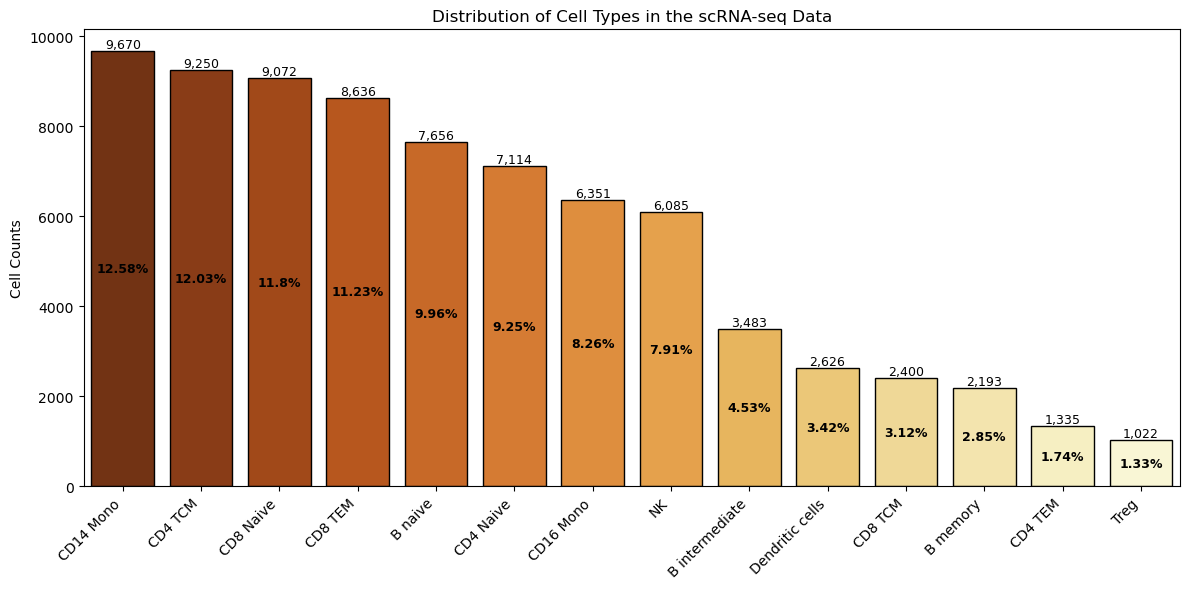

In [8]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x        = "CellType", 
    y        = "Count", 
    data     = cell_type_df,
    hue      = "CellType",
    palette  = "YlOrBr_r",
    edgecolor= "black",
    legend   = False
)
for i, (count, pct) in enumerate(zip(cell_type_df["Count"], cell_type_df["Percentage"])):
    ax.text(i, count, f"{count:,}", ha="center", va="bottom", fontsize=9)
    ax.text(i, count / 2, f"{pct}%", ha="center", va="center", fontsize=9, fontweight="bold", color="black")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Cell Types in the scRNA-seq Data")
plt.xlabel("")
plt.ylabel("Cell Counts")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "cell_type_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

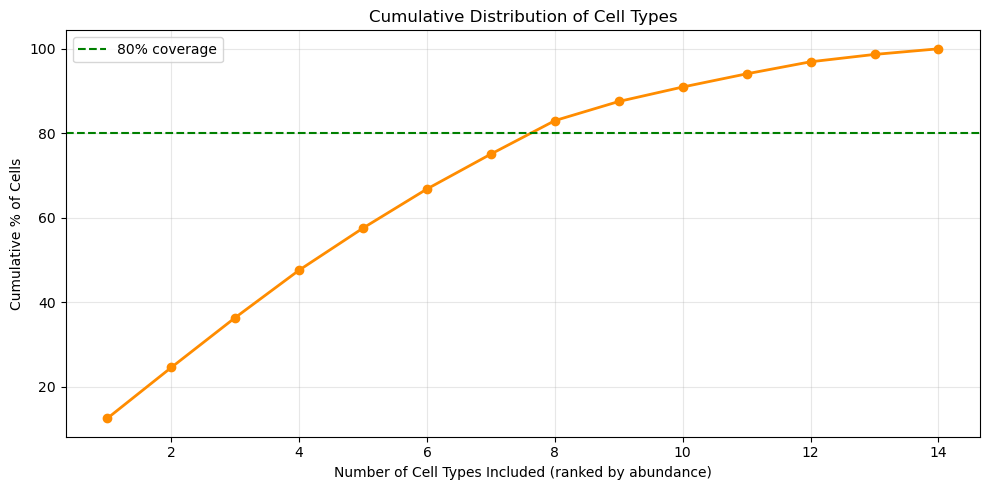

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cell_type_df) + 1),
    cell_type_df["Cumulative %"],
    marker="o", linewidth=2, color="darkorange"
)
plt.axhline(y=80, color="green", linestyle="--", label="80% coverage")
plt.xlabel("Number of Cell Types Included (ranked by abundance)")
plt.ylabel("Cumulative % of Cells")
plt.title("Cumulative Distribution of Cell Types")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "cell_type_cumulative_dist.png"), dpi=300)
plt.show()

## Analysing the gene expression features

#### Section 1 - Basicc gene statistics

In [10]:
gene_stats = rna_seq_data[gene_columns].describe().T
gene_stats["variance"] = rna_seq_data[gene_columns].var()

print(f"No. of gene features are: {len(gene_columns):,}")
print(f"Mean expression across all genes: {gene_stats['mean'].mean():.4f}")
print(f"Median expression across all genes: {gene_stats['50%'].median():.4f}")

gene_stats

No. of gene features are: 2,000
Mean expression across all genes: 0.2204
Median expression across all genes: 0.0096


,count,mean,std,min,25%,50%,75%,max,variance
PPBP,76893.0,0.014937,0.176766,-0.725410,-0.001592,0.000000,0.008731,5.930512,0.031246
PTGDS,76893.0,0.060576,0.365192,-2.035442,-0.001603,0.000000,0.011320,6.226783,0.133365
GNLY,76893.0,0.698986,1.550522,-1.973344,-0.007438,0.019588,0.225156,8.540149,2.404119
FCER1A,76893.0,0.033483,0.235844,-1.531776,-0.001314,0.000000,0.003722,3.848725,0.055622
PF4,76893.0,0.008269,0.124765,-0.791608,-0.000488,0.000000,0.004608,4.685923,0.015566
...,...,...,...,...,...,...,...,...,...
CD1B,76893.0,0.000702,0.028308,-0.324881,-0.000001,0.000000,0.000024,1.797369,0.000801
PPIL2,76893.0,0.161699,0.321841,-0.748636,0.000000,0.077906,0.174388,3.179303,0.103582
TCF19,76893.0,0.010005,0.124951,-1.139198,-0.007280,0.000000,0.011740,4.199174,0.015613
PRKCB,76893.0,0.687086,0.660020,-0.796586,0.125547,0.572383,1.102327,5.307954,0.435627


In [11]:
# Top and bottom variable genes
top_variable_genes = gene_stats.nlargest(20, "variance")
most_stable_genes = gene_stats.nsmallest(20, "variance")

print("Top 10 most variable genes:")
print(top_variable_genes[["mean", "std", "min", "max", "variance"]].head(10))

print("\nTop 10 most stable genes:")
print(most_stable_genes[["mean", "std", "min", "max", "variance"]].head(10))

Top 10 most variable genes:
             mean       std       min       max  variance
LYZ      1.225221  1.702253 -1.628624  6.118199  2.897666
HLA-DRA  1.482271  1.680197 -1.683319  5.496494  2.823062
S100A9   1.269072  1.659681 -1.254348  6.884811  2.754541
CD74     1.733779  1.581116 -2.140496  5.509888  2.499926
GNLY     0.698986  1.550522 -1.973344  8.540149  2.404119
NKG7     0.806539  1.468301 -1.021344  5.501286  2.155909
CTSS     1.448828  1.430557 -0.961517  5.864388  2.046495
S100A8   0.833182  1.425590 -1.163305  6.617430  2.032307
S100A4   2.044324  1.393723 -1.308200  5.620681  1.942463
CCL5     0.756871  1.382999 -2.174250  6.434173  1.912687

Top 10 most stable genes:
            mean       std       min       max  variance
GATA2   0.000243  0.016626 -0.262020  1.652327  0.000276
PKMYT1  0.000321  0.017562 -0.189257  1.732948  0.000308
TAL1    0.000373  0.019137 -0.411574  1.840625  0.000366
LCN2    0.000239  0.021168 -0.396733  2.266703  0.000448
CNRIP1  0.000500  0.02

Stable is not a biological terminology here. It just implies that these genes have little to no variance, hence practically stable.

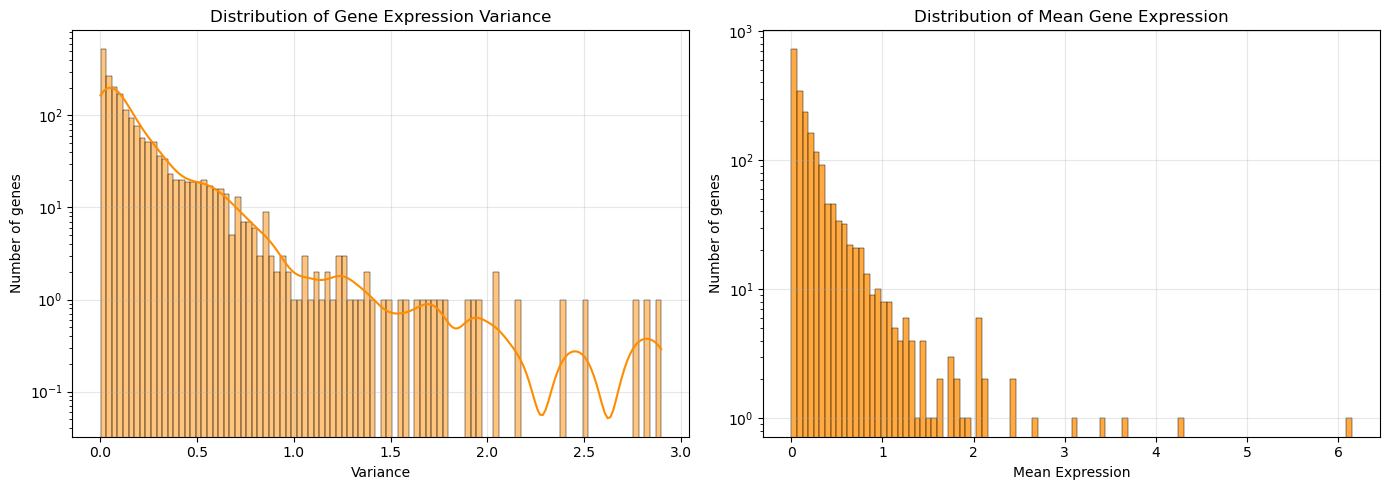

In [12]:
#Distribution of gene expression variance and mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(gene_stats["variance"], bins=100, kde=True, color="darkorange", ax=axes[0])
axes[0].set_title("Distribution of Gene Expression Variance")
axes[0].set_xlabel("Variance")
axes[0].set_ylabel("Number of genes")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)

sns.histplot(gene_stats["mean"], bins=100, color="darkorange", ax=axes[1])
axes[1].set_title("Distribution of Mean Gene Expression")
axes[1].set_xlabel("Mean Expression")
axes[1].set_ylabel("Number of genes")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "gene_expression_stats_distributions.png"), dpi=300)
plt.show()

The mean and variance expression plots are both heavily right skewed. That implies, a large majorityof the genes are stacked near low variance and zero mean expression. A meagre small subset of genes lie on the higher end of the mean and variance values. This further implies that a vast majority of the genes are restricted, whereas as a small minority of genes show tremensously high gene expression levels.   

#### Section 2 - Sparsity adjacent metric

In [13]:
# Reproducing the "sparsity" adjacent metric for comparability
zero_pct = (rna_seq_data[gene_columns] == 0).sum() / len(rna_seq_data) * 100
gene_stats["zero_percent"] = zero_pct

print(f"Average 'zero percentage' across genes: {gene_stats['zero_percent'].mean():.2f}%")

high_zero_genes = gene_stats[gene_stats["zero_percent"] > 90]
print(
    f"{len(high_zero_genes):,} genes "
    f"({len(high_zero_genes)/len(gene_columns)*100:.2f}%) "
    f"show >90% exact-zero values"
)

Average 'zero percentage' across genes: 17.43%
0 genes (0.00%) show >90% exact-zero values


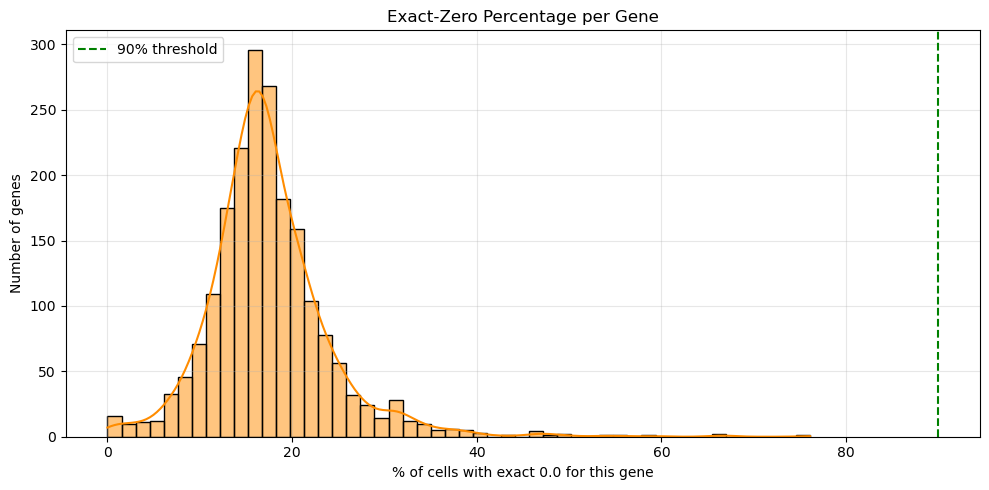

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(gene_stats["zero_percent"], bins=50, kde=True, color="darkorange" )
plt.axvline(x=90, color="green", linestyle="--", label="90% threshold")
plt.title("Exact-Zero Percentage per Gene")
plt.xlabel("% of cells with exact 0.0 for this gene")
plt.ylabel("Number of genes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "gene_sparsity_distribution.png"), dpi=300)
plt.show()

__What these numbers actually mean for our data:__

In general, we understand sparsity as a large number of zero values in our gene expression matrix. This implies that wherever a zero appears, that gene is not expressed in this cell at all. But an important note about our data frame `rna_seq_data` is that it has been scaled, log normalised and batch corrected. Which means whatever actual zero gene expresion values existed, have been scaled, normalised and have gotten adjusted. Thus, the zeros in this file are not representative of zero gene expresison. And consequently, the 17.43% sparsity figure, should not be misinterpreted as -  "*17.43% of cells have no detected expression across all genes*". 

Rather, the correct interpretation is that a 0.0 in our data indicates a cell landing exactly at that gene's post normalization mean. So the inference here is - "*17.43% of the cells have gene expressions that coincides with that gene's post normalisation mean*" 

#### Section 3 - MEan variance plot; raw variance based HVG and f statistic

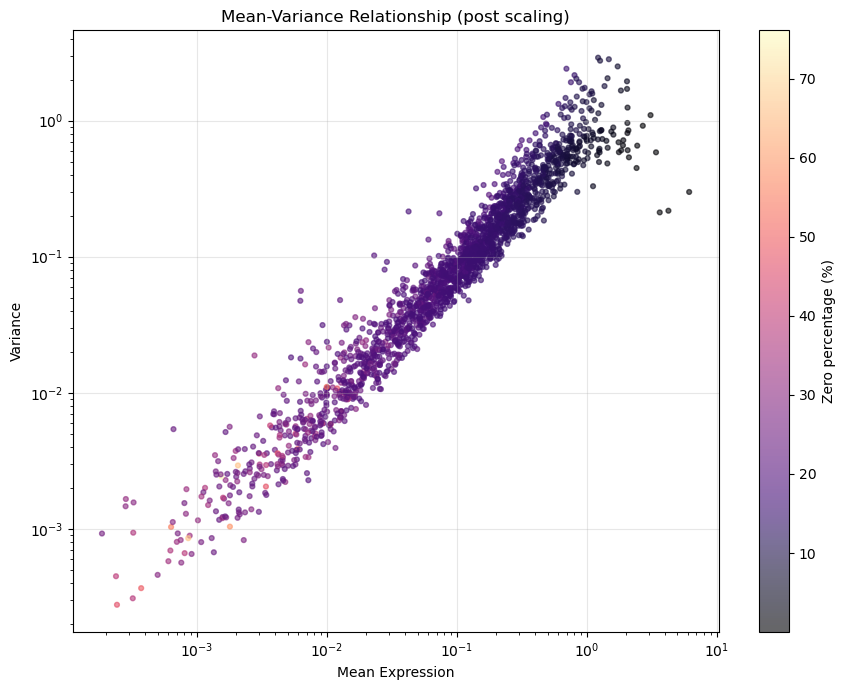

In [30]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    gene_stats["mean"],
    gene_stats["variance"],
    c=gene_stats["zero_percent"],
    cmap="magma",
    alpha=0.6,
    s=12
)
plt.colorbar(sc, label="Zero percentage (%)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean Expression")
plt.ylabel("Variance")
plt.title("Mean-Variance Relationship (post scaling)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "mean_variance_relationship.png"), dpi=300)
plt.show()

In [16]:
correlation = gene_stats[["mean", "variance"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation between mean and variance: {correlation:.3f}")

Spearman correlation between mean and variance: 0.977


The scatter plot shows a tremendously positive log-log relatioship between the per gene mean expression and variance, as indicated by the __0.977__ spearman coefficient. Practical implication of this tight coupling of mean and variance is that the ranking of genes by high variability would result automatically reproducing the ranking my mean expression. The entire purpose of selecting top 100 or 200 HVGs would be defeated. This could emphasize the __f-statistic__ approach over the raw variance based HVG (Highly variable genes) selection approach. 

In [17]:
# mean and variance for each gene for each cell type
cell_types = rna_seq_data["CellType"].unique()

group_means = {}
group_vars = {}

for ct in cell_types:
    subset = rna_seq_data[rna_seq_data["CellType"] == ct]
    group_means[ct] = subset[gene_columns].mean()
    group_vars[ct] = subset[gene_columns].var()

In [18]:
# Between-group variance: how much do cell-type means differ from the overall mean, weighted by group size
overall_mean = rna_seq_data[gene_columns].mean()
n_total = len(rna_seq_data)

between_group_var = pd.Series(0.0, index=gene_columns)
for ct in cell_types:
    weight = (rna_seq_data["CellType"] == ct).sum() / n_total
    between_group_var += weight * (group_means[ct] - overall_mean) ** 2

In [19]:
# Within-group variance: average variance inside each cell type, weighted by group size
within_group_var = pd.Series(0.0, index=gene_columns)
for ct in cell_types:
    weight = (rna_seq_data["CellType"] == ct).sum() / n_total
    within_group_var += weight * group_vars[ct]

In [20]:
# F-statistic: ratio of between-group to within-group variance
f_statistic = between_group_var / (within_group_var + 1e-10)  # small constant avoids divide-by-zero

top_markers = f_statistic.sort_values(ascending=False)
print("Top 20 potential marker genes by F-statistic:")
print(top_markers.head(20))

Top 20 potential marker genes by F-statistic:
CST3        8.718350
HLA-DRA     8.096821
TYROBP      7.973044
MS4A1       6.608455
CD79A       6.466492
FGL2        6.287146
NKG7        5.997286
MNDA        5.864057
CYBB        5.797657
IFI30       5.779139
FCN1        5.701225
LST1        5.631047
AIF1        5.351633
SERPINA1    5.204537
S100A9      4.967895
LYZ         4.729510
TMEM176B    4.690611
FCER1G      4.689236
VCAN        4.649631
CD74        4.566773
dtype: float64


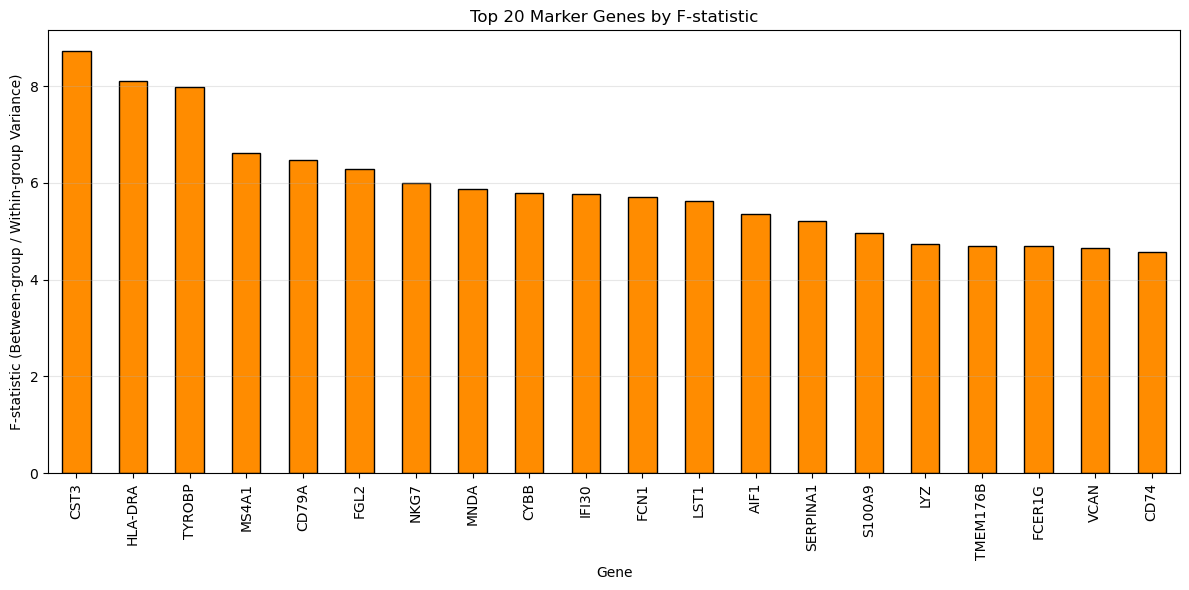

In [34]:
# Bar chart of top 20 marker genes by F-statistic
plt.figure(figsize=(12, 6))
top_markers.head(20).plot(kind="bar", color="darkorange", edgecolor="black")
plt.title("Top 20 Marker Genes by F-statistic")
plt.xlabel("Gene")
plt.ylabel("F-statistic (Between-group / Within-group Variance)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "top_marker_genes.png"), dpi=300)
plt.show()

__F-statistic__ vs raw variance comparison of the rankings:

In the begining of this section we used the raw variance to pull out the top 10 most variable and the top 10 most stable genes. Among the top 10 most variable genes, we observed  - `HLA-DRA, NKG7, S100A9, LYZ, and CD74`, all five of which also appear in the top 20 potential markers as ranked by the f statistic. These overlapping genes are strong signaling, regardless of the method. But meaningful differnece do arise, in the sense that `LYZ`, the highest ranked #1 gene by raw variance, got ranked #16 by F-statistic. And conversely, several of the top 10 genes as ranked by the F-statistic method (namely `MS4A1, CD79A`) do not appear in the ranking by raw variance at all. This further brings into significance the mean-variance coupling observed earlier: genes with high overall variance are not necessarily the genes that best discriminate between cell types, which is the actual goal of this entire HVG selection process.

In [21]:
# Top genes by each method
N_GENES = 15
top_variance_gene_names = gene_stats.nlargest(N_GENES, "variance").index
top_fstat_gene_names = top_markers.head(N_GENES).index

# Mean expression per cell type, for each gene set
def mean_expr_by_celltype(gene_names):
    result = pd.DataFrame()
    for ct in cell_types:
        subset = rna_seq_data[rna_seq_data["CellType"] == ct]
        result[ct] = subset[gene_names].mean()
    return result

variance_heatmap_data = mean_expr_by_celltype(top_variance_gene_names)
fstat_heatmap_data = mean_expr_by_celltype(top_fstat_gene_names)

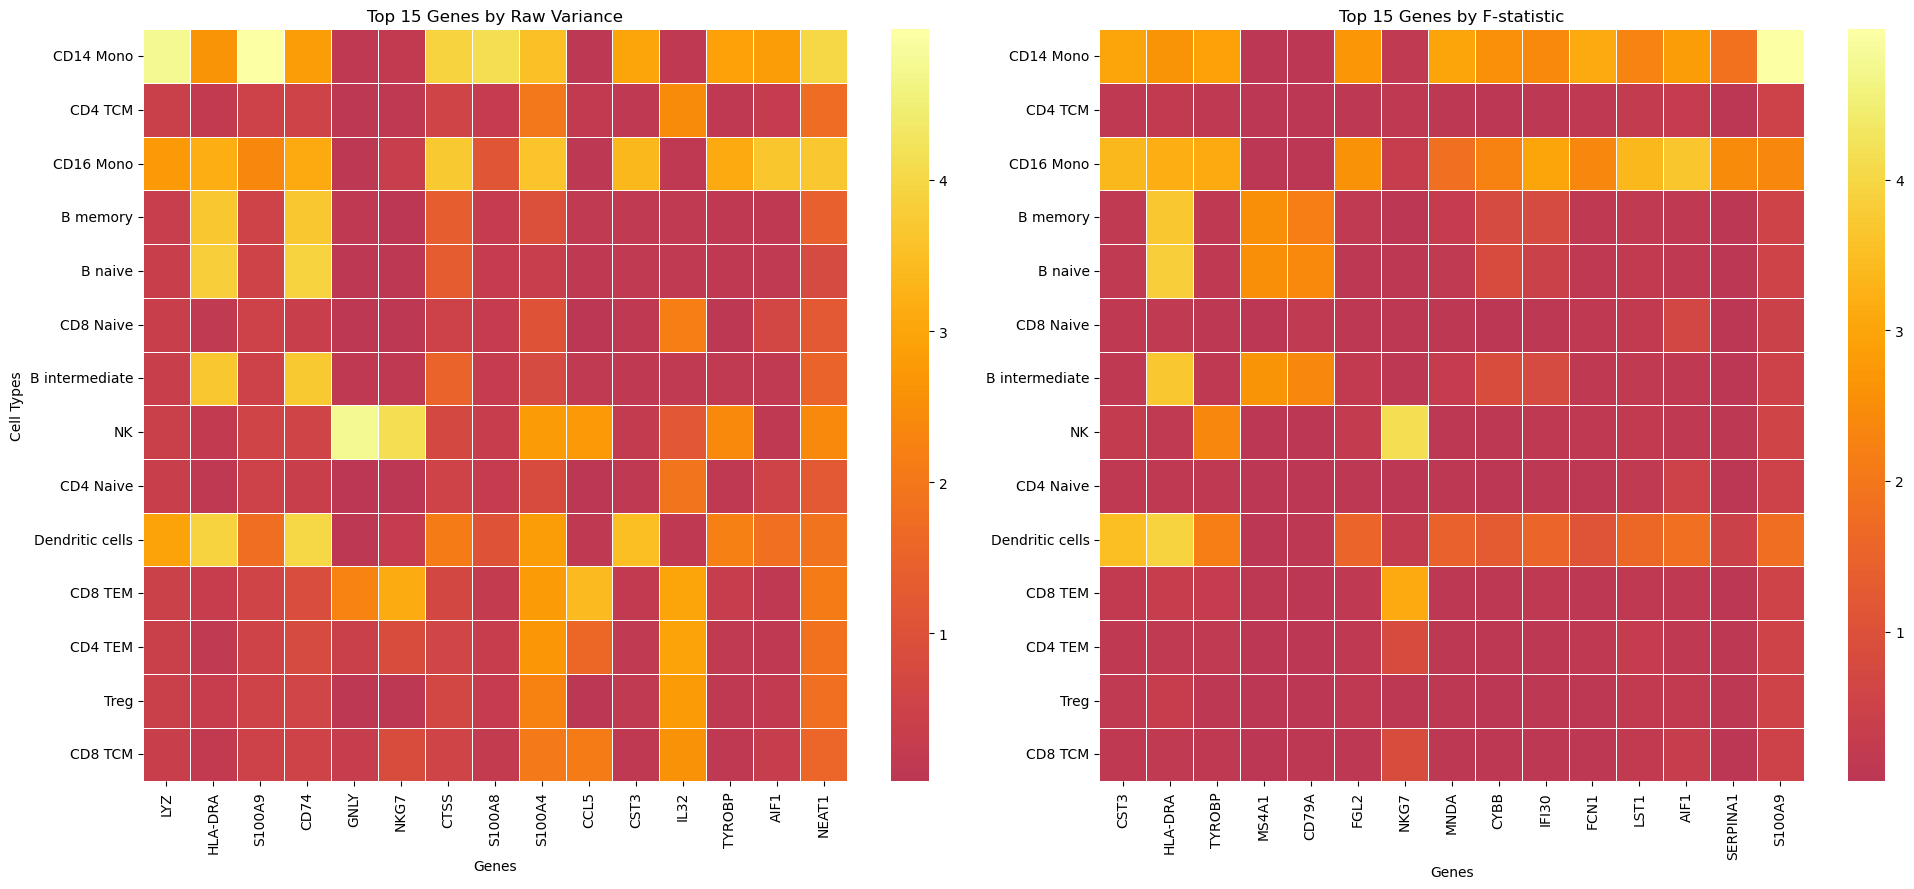

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(variance_heatmap_data.T, cmap="inferno", center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title(f"Top {N_GENES} Genes by Raw Variance")
axes[0].set_xlabel("Genes")
axes[0].set_ylabel("Cell Types")

sns.heatmap(fstat_heatmap_data.T, cmap="inferno", center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title(f"Top {N_GENES} Genes by F-statistic")
axes[1].set_xlabel("Genes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "top_genes_heatmap_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

The two heatmaps ask inherently different questions about gene variability. Raw variance on the left asks: "Which genes vary the most across all cells, regardless of why?" This variability could come from cell-type differences, activation states, individual cell noise, or a handful of extreme values. The raw variance is cause agnostic of these values.

F-statistic on the right asks a more targeted question: "Which genes differ most systematically between cell types, relative to variation within each cell type?" A high F-statistic means cells of different types express the gene very differently, while cells of the *same* type are relatively consistent. That is the kind of inference which makes a gene a good classification feature. Only 6 genes overlap between the two top-15 lists: `HLA-DRA`, `CST3`, `TYROBP`, `NKG7`, `AIF1`, `S100A9`. The two methods are picking up substantially different signals.

**Raw variance** gives us genes reflecting broad transcriptional activity i.e. `GNLY`, `NKG7`, `CCL5` (cytotoxic lymphocyte/NK activity), `S100A8`/`S100A9`/`LYZ` (inflammatory myeloid activity). These genes have large oscillations in expression somewhere in the dataset, but that isn't guaranteed to align nevccesssarily with cell-type boundaries. **F-statistic** gives us genes that are more evidently organized around lineage identity i.e. `MS4A1`/`CD79A` (B cells), `FCN1`/`LST1`/`SERPINA1`/`CYBB` (monocyte/myeloid), `NKG7` (NK/cytotoxic). Notably, `MS4A1` and `CD79A`, which are known to be clean, canonical B-cell markers, are absent from the raw-variance list entirely, despite being highly discriminative, because B cells are a smaller population and their expression differences don't dominate overall dataset variance the way the largest class (CD14 Mono) does.


**Important caveat on reading the figure:** the heatmap color intensity represents each gene's mean expression level per cell type, not its variance or F-statistic value. Variance/F-statistic were only used to selectcwhich 15 genes to plot; the colors themselves show a different quantity. Since our eventual goal is cell-type classification, the relevant question isn't "which genes vary the most" but "which genes help distinguish cell types from one another." The F-statistic is a more direct measure of that property, and the heatmap comparison supports using F-statistic-based (rather than raw-variance-based) gene selection going forward.

In [36]:
#Dimensionality characteristics summary

n_cells, n_genes = rna_seq_data.shape[0], len(gene_columns)

print("Dataset dimensionality characteristics:")
print(f"Number of samples (cells): {n_cells:,}")
print(f"Number of features (genes): {n_genes:,}")
print(f"Feature-to-sample ratio: {n_genes / n_cells:.4f}")

Dataset dimensionality characteristics:
Number of samples (cells): 76,893
Number of features (genes): 2,000
Feature-to-sample ratio: 0.0260


In [32]:
# Overall matrix "zero percentage" (same caveat as the earlier per-gene sparsity metric)
total_zeros = (rna_seq_data[gene_columns] == 0).sum().sum()
total_elements = rna_seq_data[gene_columns].size
zero_matrix_pct = (total_zeros / total_elements) * 100

print(f"Overall exact-zero percentage across the full matrix: {zero_matrix_pct:.2f}%")
print(f"Non-zero elements: {total_elements - total_zeros:,} ({100 - zero_matrix_pct:.2f}% of matrix)")

Overall exact-zero percentage across the full matrix: 17.43%
Non-zero elements: 126,986,490 (82.57% of matrix)


While the F-statistic more directly targets between-cell-type discriminative power, raw variance remains a standard and widely used criterion for highly variable gene (HVG) selection in single-cell transcriptomics. It is the default approach in established tools such as Seurat's `FindVariableFeatures()` and Scanpy's `highly_variable_genes()`. It has two practical advantages that matter for this stage of the pipeline:

1. **Label independence.** Raw variance is computed without reference to cell-type labels, making it a valid unsupervised feature selection step — appropriate for a pipeline stage that also feeds into unsupervised clustering and visualization (PCA/t-SNE/UMAP), not only the eventual supervised classification task. F-statistic selection, by contrast, uses the labels directly, which risks a subtle form of information leakage if the same gene set is later reused to evaluate how well unsupervised clustering recovers those same labels.
2. **Established precedent.** Raw-variance HVG selection is the conventional first step in the scRNA-seq analysis workflows this project builds on, and keeping this step consistent with standard practice makes the pipeline's dimensionality-reduction results easier to sanity-check against typical published scRNA-seq analyses.

We therefore proceed with raw-variance-based HVG selection for the dimensionality reduction and clustering steps that follow.

## Feature engineering and selection: Dimensionality REduction 

In [39]:
#Specific imports for thiss section

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

In [46]:
def run_dimensionality_reduction_eda(data, gene_cols, random_seed=RAND_SEED):
    """
    Comprehensive dimensionality reduction EDA for scRNA-seq data.
    Tests HVG subset sizes [50, 100] with PCA, t-SNE, and UMAP.
    Returns results for all tested HVG sizes (no automatic selection).
    """
    print("=== Dimensionality Reduction Analysis ===")

    X = data[gene_cols].values
    y = data["CellType"].values

    print("\nSelecting highly variable genes (HVGs)...")
    gene_var = np.var(X, axis=0)
    var_df = pd.DataFrame({"Gene": list(gene_cols), "Variance": gene_var}).sort_values("Variance", ascending=False)

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.hist(np.log10(var_df["Variance"] + 1e-10), bins=100)
    plt.xlabel("log10(Variance)")
    plt.ylabel("Number of Genes")
    plt.title("Distribution of Gene Expression Variance")

    plt.subplot(1, 2, 2)
    plt.plot(np.arange(1, 101), var_df["Variance"].iloc[:100], "o-")
    plt.xlabel("Gene Rank")
    plt.ylabel("Variance")
    plt.title("Top 100 Most Variable Genes")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "hvg_variance_distribution.png"), dpi=300)
    plt.show()

    top_n_genes = [50, 100]
    results = {}

    for n in top_n_genes:
        print(f"\nAnalyzing with top {n} HVGs...")
        top_genes = var_df["Gene"].iloc[:n].tolist()
        X_hvg = data[top_genes].values

        print("Standardizing data...")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_hvg)

        print("Running PCA...")
        pca = PCA(random_state=random_seed)
        X_pca = pca.fit_transform(X_scaled)

        explained_var = pca.explained_variance_ratio_
        cumulative_var = np.cumsum(explained_var)

        thresholds = [0.5, 0.7, 0.9, 0.95, 0.99]
        components_needed = [np.argmax(cumulative_var >= t) + 1 for t in thresholds]

        plt.figure(figsize=(16, 6))
        plt.subplot(1, 2, 1)
        plt.bar(range(1, min(31, len(explained_var) + 1)), explained_var[:30] * 100)
        plt.xlabel("Principal Component")
        plt.ylabel("Explained Variance (%)")
        plt.title(f"PCA Explained Variance (Top {n} HVGs)")

        plt.subplot(1, 2, 2)
        plt.plot(range(1, min(101, len(cumulative_var) + 1)), cumulative_var[:100] * 100, "o-")
        for t, comp in zip(thresholds, components_needed):
            plt.axhline(y=t * 100, color=f"C{thresholds.index(t) + 1}", linestyle="--",
                        label=f"{int(t*100)}% var: {comp} PCs")
        plt.xlabel("Number of Principal Components")
        plt.ylabel("Cumulative Explained Variance (%)")
        plt.title("Cumulative Explained Variance")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, f"pca_variance_{n}_hvgs.png"), dpi=300)
        plt.show()

        print("Running t-SNE...")
        tsne = TSNE(n_components=2, random_state=random_seed, perplexity=30)
        X_tsne = tsne.fit_transform(X_scaled)

        print("Running UMAP...")
        reducer = umap.UMAP(random_state=random_seed, n_neighbors=15, min_dist=0.1)
        X_umap = reducer.fit_transform(X_scaled)

        viz_data = {
            "pca": pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Cell Type": y}),
            "tsne": pd.DataFrame({"tSNE1": X_tsne[:, 0], "tSNE2": X_tsne[:, 1], "Cell Type": y}),
            "umap": pd.DataFrame({"UMAP1": X_umap[:, 0], "UMAP2": X_umap[:, 1], "Cell Type": y}),
        }

        cell_types_local = data["CellType"].unique()
        n_colors = len(cell_types_local)
        colors = sns.color_palette("tab20", n_colors=min(20, n_colors))
        colors += sns.color_palette("tab20b", n_colors=max(0, n_colors - 20))

        fig, axes = plt.subplots(1, 3, figsize=(24, 7))
        sns.scatterplot(data=viz_data["pca"], 
                        x="PC1", 
                        y="PC2", 
                        hue="Cell Type", 
                        palette=colors, 
                        s=30, alpha=0.7, ax=axes[0])
        axes[0].set_title(f"PCA - Top {n} HVGs", fontsize=14)

        sns.scatterplot(data=viz_data["tsne"], 
                        x="tSNE1", 
                        y="tSNE2", 
                        hue="Cell Type", 
                        palette=colors, 
                        s=30, alpha=0.7, ax=axes[1])
        axes[1].set_title(f"t-SNE - Top {n} HVGs", fontsize=14)

        sns.scatterplot(data=viz_data["umap"], 
                        x="UMAP1", 
                        y="UMAP2", 
                        hue="Cell Type", 
                        palette=colors, 
                        s=30, alpha=0.7, ax=axes[2])
        axes[2].set_title(f"UMAP - Top {n} HVGs", fontsize=14)

        for ax in axes:
            ax.get_legend().remove()
            ax.grid(True, linestyle="--", alpha=0.7)

        handles, labels = axes[0].get_legend_handles_labels()
        if len(labels) > 20:
            top_cell_types = data["CellType"].value_counts().nlargest(19).index.tolist()
            fig.legend(
                [h for h, l in zip(handles, labels) if l in top_cell_types] + [handles[0]],
                [l for l in labels if l in top_cell_types] + ["Other Cell Types"],
                loc="right", bbox_to_anchor=(1.05, 0.5), title="Cell Types"
            )
        else:
            fig.legend(handles, labels, loc="right", bbox_to_anchor=(1.05, 0.5), title="Cell Types")

        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.suptitle(f"Dimensionality Reduction Comparison - Top {n} HVGs", y=1.02, fontsize=16)
        plt.savefig(os.path.join(PLOT_DIR, f"dim_reduction_comparison_{n}_hvgs.png"), dpi=300, bbox_inches="tight")
        plt.show()

        le = LabelEncoder()
        y_encoded = le.fit_transform(y)

        try:
            sil_pca = silhouette_score(X_pca[:, :min(50, X_pca.shape[1])], y_encoded)
            sil_tsne = silhouette_score(X_tsne, y_encoded)
            sil_umap = silhouette_score(X_umap, y_encoded)
            print(f"\nCell type separability (silhouette scores):")
            print(f"PCA (50 components): {sil_pca:.3f}")
            print(f"t-SNE: {sil_tsne:.3f}")
            print(f"UMAP: {sil_umap:.3f}")
        except Exception as e:
            print(f"Could not compute silhouette scores: {e}")

        results[n] = {
            "pca": X_pca, "tsne": X_tsne, "umap": X_umap,
            "top_genes": top_genes,
            "explained_var": explained_var,
            "cumulative_var": cumulative_var,
            "components_needed": {t: c for t, c in zip(thresholds, components_needed)},
        }

    plt.figure(figsize=(10, 6))
    for n, res in results.items():
        plt.plot(range(1, 51), res["cumulative_var"][:50] * 100, label=f"Top {n} HVGs")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance (%)")
    plt.title("PCA Performance with Different Numbers of HVGs")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "pca_comparison_across_hvgs.png"), dpi=300)
    plt.show()

    summary_df = pd.DataFrame([
        {
            "Num HVGs": n,
            "PCs for 50% var": res["components_needed"][0.5],
            "PCs for 70% var": res["components_needed"][0.7],
            "PCs for 90% var": res["components_needed"][0.9],
            "PCs for 95% var": res["components_needed"][0.95],
            "PCs for 99% var": res["components_needed"][0.99],
        }
        for n, res in results.items()
    ])
    print("\nDimensionality reduction summary table:")
    print(summary_df)

    # Return the full results dict for all tested HVG sizes — selection is made manually, outside this function
    return results

=== Dimensionality Reduction Analysis ===

Selecting highly variable genes (HVGs)...


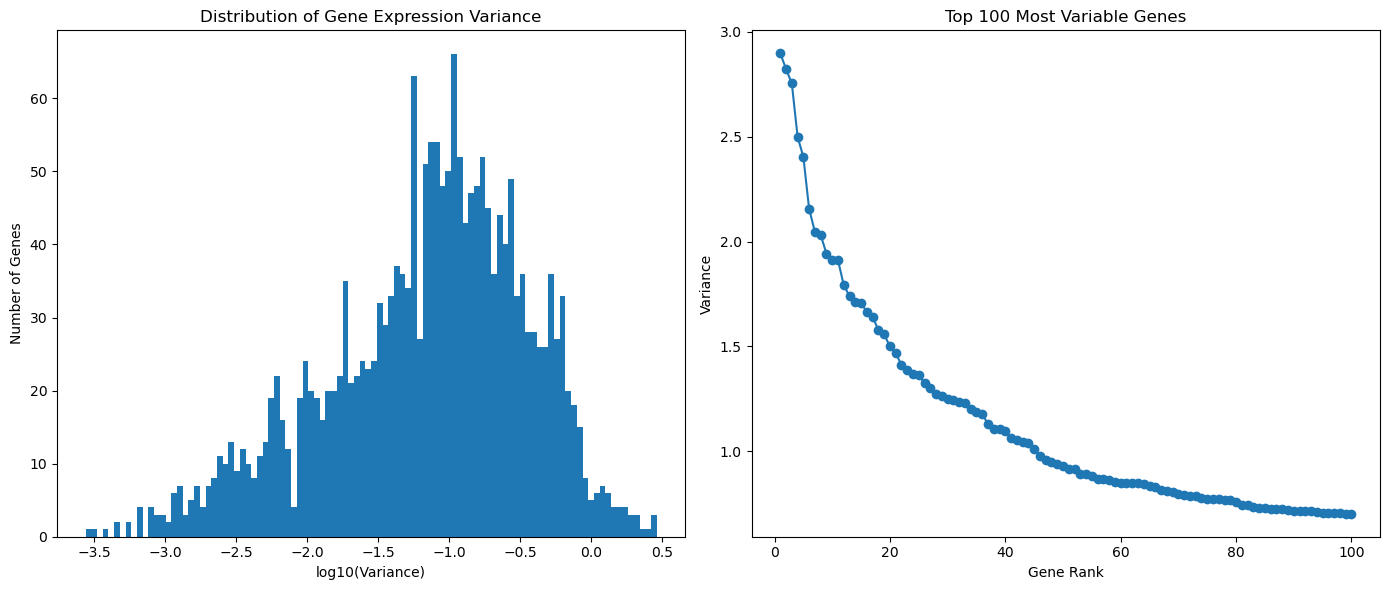


Analyzing with top 50 HVGs...
Standardizing data...
Running PCA...


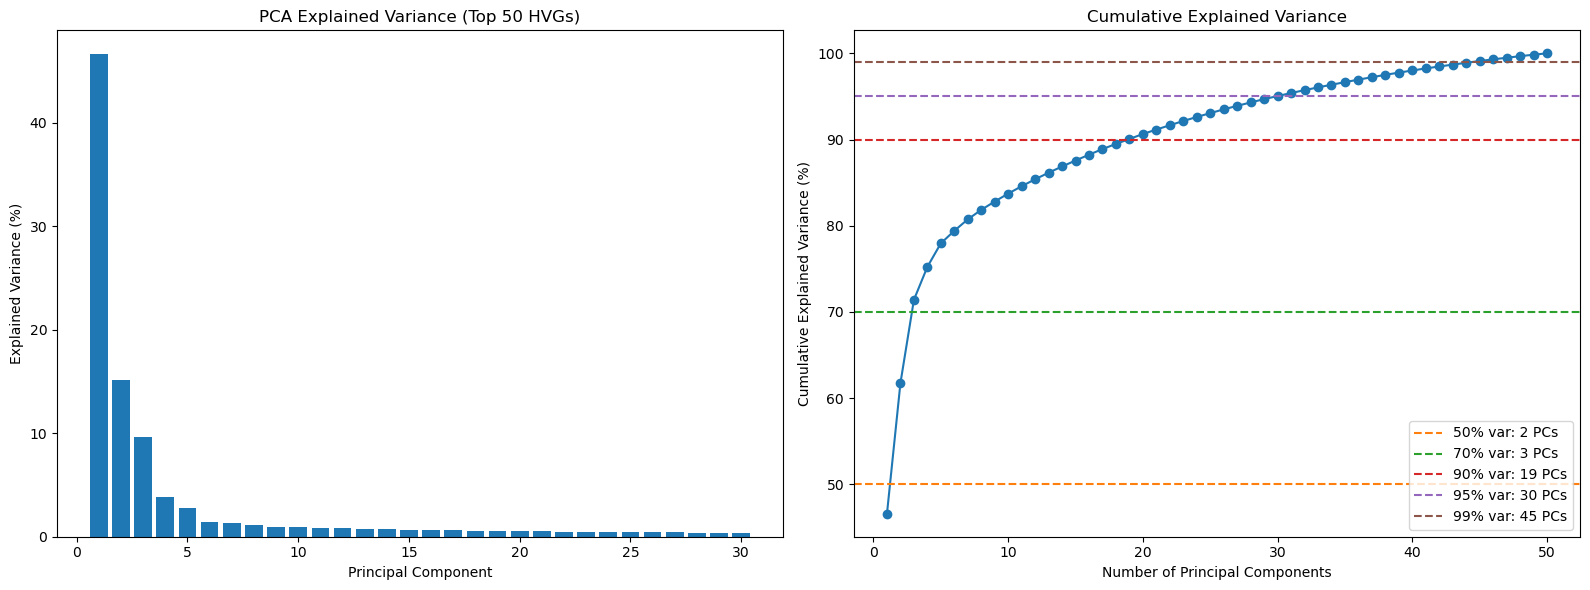

Running t-SNE...
Running UMAP...


/home/rajan/miniforge3/envs/immune_ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


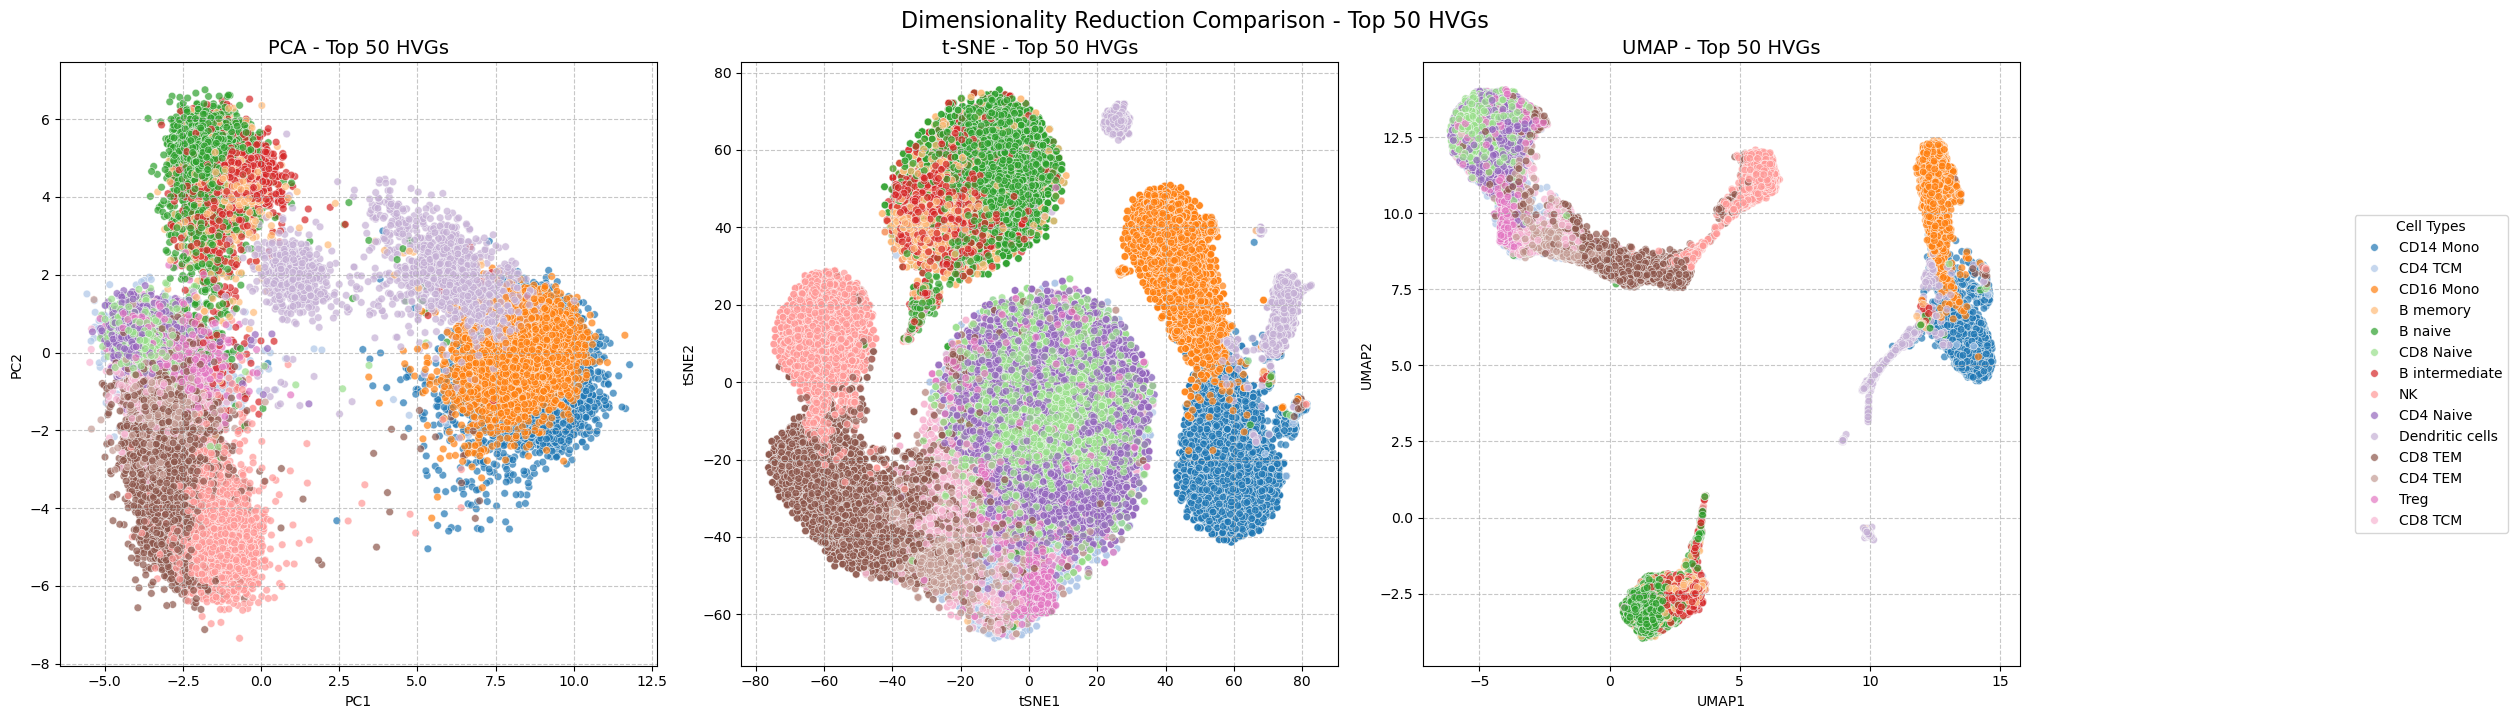


Cell type separability (silhouette scores):
PCA (50 components): 0.095
t-SNE: 0.183
UMAP: 0.232

Analyzing with top 100 HVGs...
Standardizing data...
Running PCA...


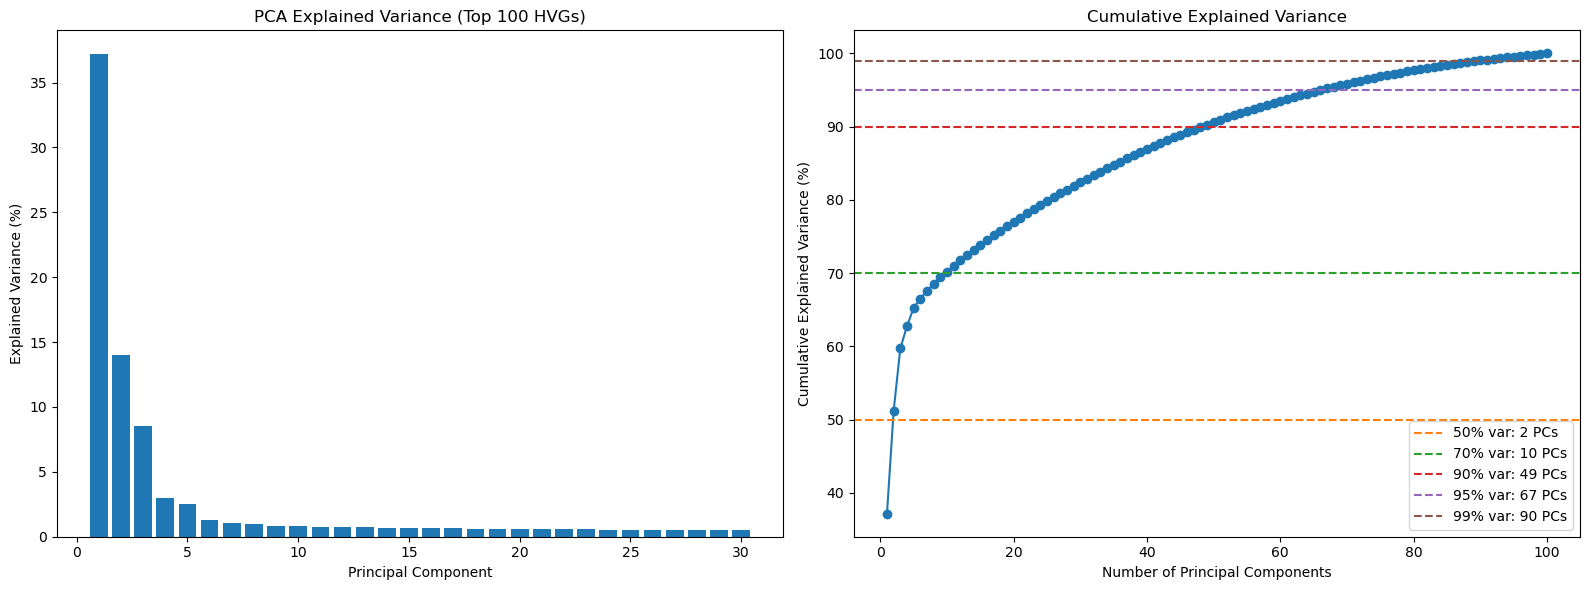

Running t-SNE...
Running UMAP...


/home/rajan/miniforge3/envs/immune_ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


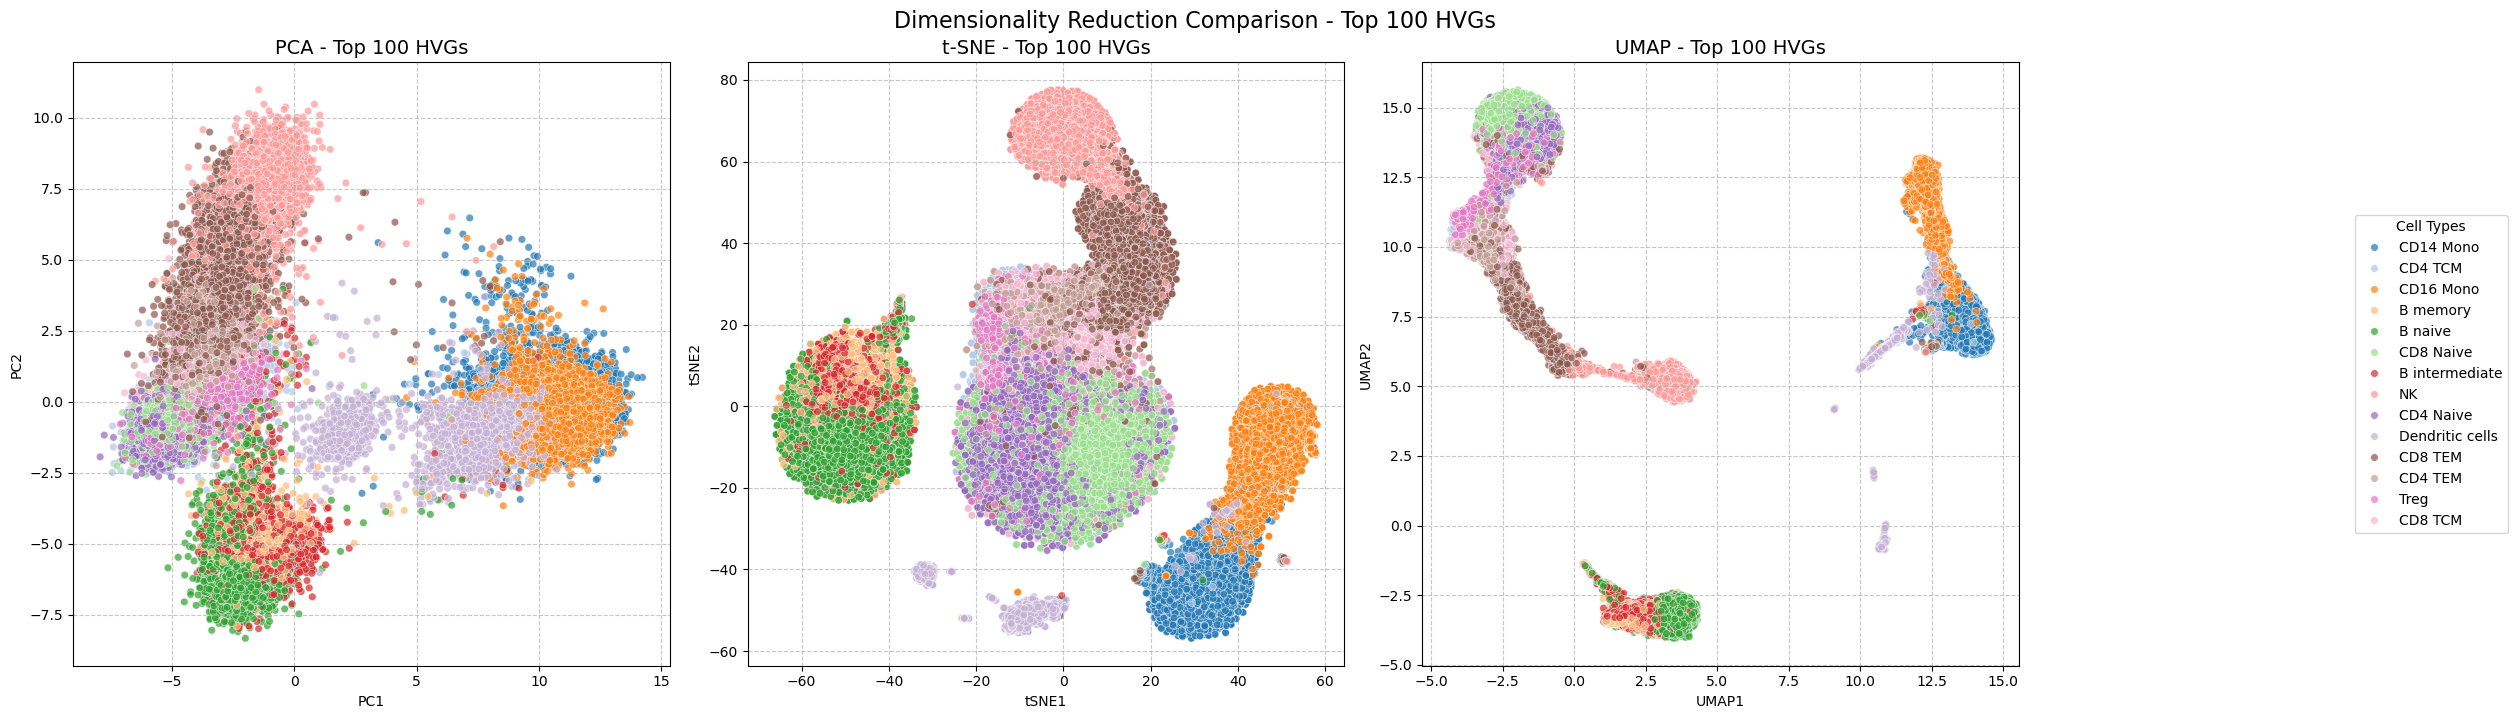


Cell type separability (silhouette scores):
PCA (50 components): 0.081
t-SNE: 0.244
UMAP: 0.262


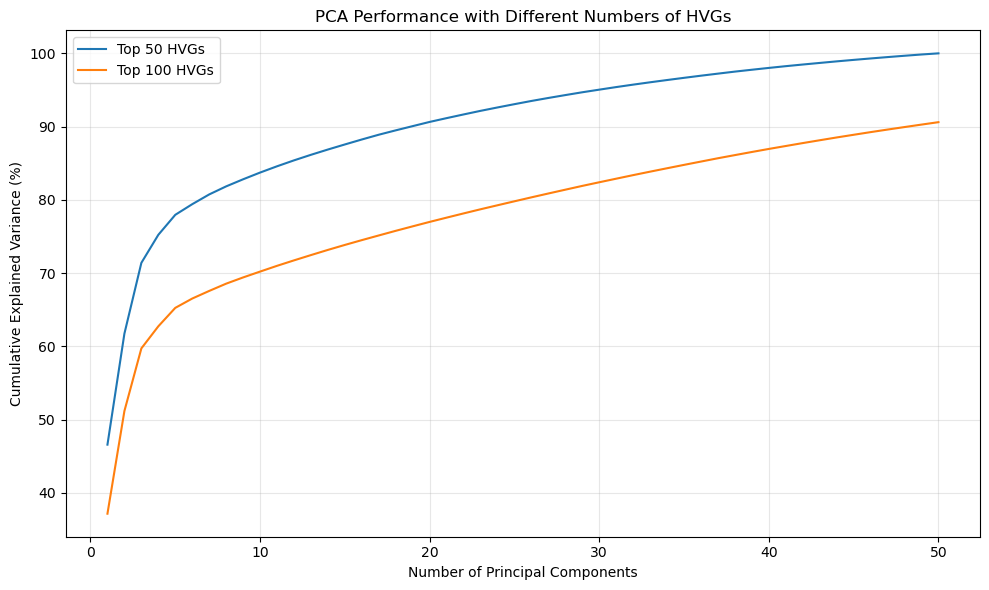


Dimensionality reduction summary table:
   Num HVGs  PCs for 50% var  PCs for 70% var  PCs for 90% var  \
0        50                2                3               19   
1       100                2               10               49   

   PCs for 95% var  PCs for 99% var  
0               30               45  
1               67               90  


KeyError: 'top_genes'

In [47]:
dim_reduction_results = run_dimensionality_reduction_eda(rna_seq_data, gene_columns)

optimal_hvgs = dim_reduction_results["top_genes"]
optimal_n_components = dim_reduction_results["components_needed"][0.9]

feature_selection_results = {
    "optimal_hvgs": optimal_hvgs,
    "optimal_n_components": optimal_n_components,
    "pca_variance_ratio": dim_reduction_results["explained_var"],
    "pca_cumulative_variance": dim_reduction_results["cumulative_var"],
}

with open(os.path.join(RESULTS_DIR, "feature_selection_results.pkl"), "wb") as f:
    pickle.dump(feature_selection_results, f)

print(f"\nSaved to {RESULTS_DIR}/feature_selection_results.pkl")
print(f"Selected {len(optimal_hvgs)} HVGs and {optimal_n_components} principal components")